In [2]:
import numpy as np
import globals as gl
import nibabel as nb
import os
import matplotlib.pyplot as plt
import pandas as pd
from Cython.Shadow import struct
from nitools import spm
import nitools as nt
import warnings
from hrf import inspect_hrf_params

warnings.filterwarnings("ignore")
plt.style.use('default')


Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


Loading SPM...


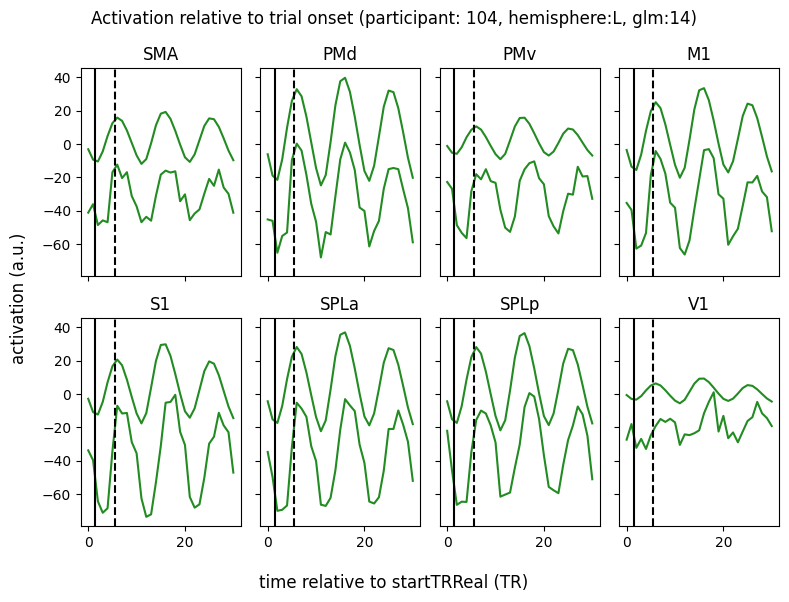

In [8]:
experiment = 'smp2'
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
r = 0
glm = 14
sn = 104

# default [6, 16, 1, 1, 6, 0, 32]
SPM = spm.SpmGlm(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}',))

print('Loading SPM...')
SPM.get_info_from_spm_mat()

g_atlas = nb.load(os.path.join(gl.atlas_dir, f'ROI.32k.{Hem}.label.gii'))

labels = {
    ele.key: getattr(ele, 'label', '')
    for ele in g_atlas.labeltable.labels
}

path_glm = os.path.join(gl.baseDir, experiment,  f'{gl.glmDir}{glm}', f'subj{sn}')

# y_hat_go = nb.load(os.path.join(path_glm, f'ROI.y_hat.go.cut.ptseries.nii'))
# y_adj_go = nb.load(os.path.join(path_glm, f'ROI.y_adj.go.cut.ptseries.nii'))
# y_hat_nogo = nb.load(os.path.join(path_glm, f'ROI.y_hat.nogo.cut.ptseries.nii'))
# y_adj_nogo = nb.load(os.path.join(path_glm, f'ROI.y_adj.nogo.cut.ptseries.nii'))

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(8, 6))
for i in range(2):
    for j in range(4):

        mask_img = os.path.join(gl.baseDir, experiment, gl.roiDir, f'subj{sn}', f'ROI.L.{rois[r]}.nii')

        coords = nt.get_mask_coords(mask_img)
        data = nt.sample_images(SPM.rawdata_files, coords)

        # rerun glm
        _, info, y_filt, y_hat, y_adj, residuals = SPM.rerun_glm(data)

        y_hat_cut = spm.cut(y_hat, 10, at, 20)
        y_adj_cut = spm.cut(y_adj, 10, at, 20)

        axs[i, j].plot(y_adj_cut.mean(axis=(0, 2)), color='forestgreen', label='go adj', ls='-')
        axs[i, j].plot(y_hat_cut.mean(axis=(0, 2)), color='forestgreen', label='go hat', ls='-')

        # axs[i, j].plot(y_adj_go.header.get_axis(0), y_adj_go.dataobj[:, r], color='magenta', label='go adj', ls='-')
        # axs[i, j].plot(y_hat_go.header.get_axis(0), y_hat_go.dataobj[:, r], color='magenta', label='go hat', ls='--')
        #
        # axs[i, j].plot(y_adj_nogo.header.get_axis(0), y_adj_nogo.dataobj[:, r], color='forestgreen', label='nogo adj', ls='-')
        # axs[i, j].plot(y_hat_nogo.header.get_axis(0), y_hat_nogo.dataobj[:, r], color='forestgreen', label='nogo hat', ls='--')

        axs[i, j].axvline(1.5, color='k', ls='-')
        axs[i, j].axvline(5.5, color='k', ls='--')

        axs[i, j].set_title(rois[r])

        r = r + 1

fig.supylabel('activation (a.u.)')
fig.supxlabel('time relative to startTRReal (TR)')
fig.suptitle(f'Activation relative to trial onset (participant: {sn}, hemisphere:{Hem}, glm:{glm})')

fig.tight_layout()

Loading SPM...


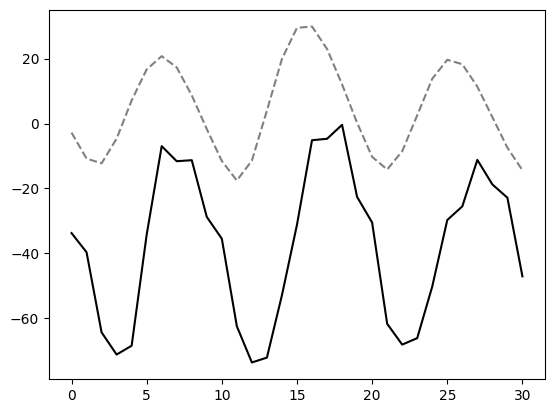

In [4]:
experiment = 'smp2'
glm = 14
sn = 104
GoNogo = 'go'
atlas = 'ROI'
roi = 'S1'
P = [6, 12, 1, 1, 6, 0, 32]

dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}',
                                   f'{experiment}_{sn}.dat'), sep='\t')
dat = dat[dat['GoNogo'] == 'go']
pinfo = pd.read_csv(os.path.join(gl.baseDir, experiment, 'participants.tsv'), sep='\t')
runs = pinfo[pinfo['sn'] == sn].FuncRuns.reset_index(drop=True)[0].split('.')
nVols = pinfo[pinfo['sn'] == sn].numTR
i = 0
for BN in dat['BN'].unique():
    if str(BN) in runs:
        if i == 0:
            at = (dat[dat['BN']==BN].startTRReal).tolist()
        else:
            at.extend((dat[dat['BN']==BN].startTRReal + int(nVols * i)).tolist())
        i =+ 1
    else:
        print(f'excluding block {BN}')

SPM = spm.SpmGlm(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}',))

print('Loading SPM...')
SPM.get_info_from_spm_mat()

mask_img = os.path.join(gl.baseDir, experiment, gl.roiDir, f'subj{sn}', f'ROI.L.{roi}.nii')

coords = nt.get_mask_coords(mask_img)
data = nt.sample_images(SPM.rawdata_files, coords)

# rerun glm
_, info, y_filt, y_hat, y_adj, residuals = SPM.rerun_glm(data)

y_hat_cut = spm.cut(y_hat, 10, at, 20)
y_adj_cut = spm.cut(y_adj, 10, at, 20)

plt.plot(y_adj_cut.mean(axis=(0, 2)), color='k', label='go adj', ls='-')
plt.plot(y_hat_cut.mean(axis=(0, 2)), color='grey', label='go hat', ls='--')

Loading SPM...
Updating hrf params...


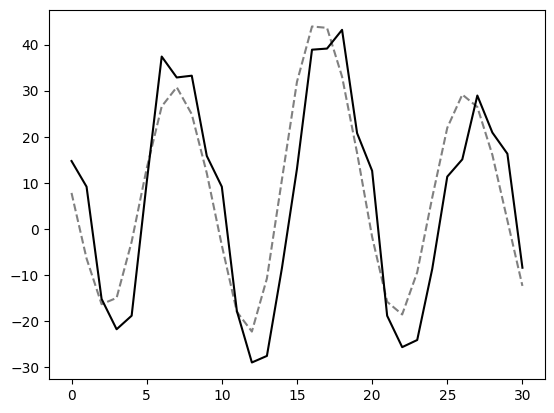

In [15]:
experiment = 'smp2'
glm = 14
sn = 104
GoNogo = 'go'
atlas = 'ROI'
roi = 'S1'
P = [6, 12, 1, 1, 6, 0, 32]

y_hat_cut, y_adj_cut = inspect_hrf_params(experiment, glm, sn, GoNogo, atlas, 'S1', P)

plt.plot(y_hat_cut.mean(axis=(0, 2)), ls='--', color='grey')
plt.plot(y_adj_cut.mean(axis=(0, 2)), ls='-', color='k')
plt.show()

In [ ]:
experiment = 'smp2'
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
sn = 104

g_atlas = nb.load(os.path.join(gl.atlas_dir, f'ROI.32k.{Hem}.label.gii'))

labels = {
    ele.key: getattr(ele, 'label', '')
    for ele in g_atlas.labeltable.labels
}

y_raw = nb.load(os.path.join(gl.baseDir, experiment,  f'{gl.glmDir}{glm}', f'subj{sn}', f'ROI.y_raw.ptseries.nii'))
y_hat = nb.load(os.path.join(gl.baseDir, experiment,  f'{gl.glmDir}{glm}', f'subj{sn}', f'ROI.y_hat.ptseries.nii'))
y_filt = nb.load(os.path.join(gl.baseDir, experiment, f'{gl.glmDir}{glm}', f'subj{sn}', f'ROI.y_filt.ptseries.nii'))
y_adj = nb.load(os.path.join(gl.baseDir, experiment, f'{gl.glmDir}{glm}',f'subj{sn}', f'ROI.y_adj.ptseries.nii'))

dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}.dat'), sep='\t')
startTimeReal = dat.startTimeReal
startTRReal = dat.startTRReal + (dat.BN - 1) * 336
iti = np.diff(startTimeReal)
start_bs = startTRReal[:-1][iti > 15000] + 8

fig, axs = plt.subplots(nrows=8, sharex=True, figsize=(6, 12))
for r, ax in enumerate(axs, start=1):

    # ax.plot(y_raw.header.get_axis(0), y_raw.dataobj[:, r], color='k', label='y_raw', ls='-')
    ax.plot(y_adj.header.get_axis(0), y_adj.dataobj[:, r], color='green', label='y_adj', ls='-')
    ax.plot(y_filt.header.get_axis(0), y_filt.dataobj[:, r], color='blue', label='y_filt', ls='-')
    ax.plot(y_hat.header.get_axis(0), y_hat.dataobj[:, r], color='red', label='y_hat', ls='--')

    for i in np.arange(1, y_hat.shape[0],336):
        ax.axvline(i, color='k', ls='-', lw=.8)

    for i in start_bs:
        ax.axvspan(i, i+10, color='grey', alpha=0.3)

    ax.set_title(labels[r])

    r = r + 1

fig.supylabel('activation (a.u.)')
fig.supxlabel('TR')

fig.suptitle(f'Adjusted and predicted activation (participant {sn})')
fig.tight_layout()